<a href="https://colab.research.google.com/github/RATHICK2951/Data-Analytics---Batch10-/blob/feature%2Frole3-eda/Telco_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/Telco_customer_churn_clean.csv")

sns.set_theme(style="whitegrid")

In [ ]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().mean()*100

,0
CustomerID,0.000000
Count,0.000000
Country,0.000000
State,0.000000
City,0.000000
Zip Code,0.000000
Lat Long,0.000000
Latitude,0.000000
Longitude,0.000000
Gender,0.000000


In [ ]:
import numpy as np
hidden_null_values=['-','n/a','missing','unknow','N/A','Null','null']
df.replace(hidden_null_values,np.nan,inplace=True)

In [ ]:
df.isnull().mean()*100

,0
CustomerID,0.000000
Count,0.000000
Country,0.000000
State,0.000000
City,0.000000
Zip Code,0.000000
Lat Long,0.000000
Latitude,0.000000
Longitude,0.000000
Gender,0.000000


# **Visualization by graphs**

# **1. Customer Churn Distribution — Count Plot**

<Axes: xlabel='Churn Label', ylabel='count'>

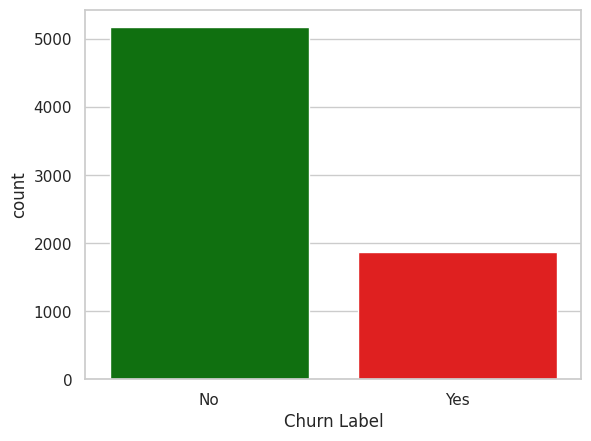

In [ ]:
sns.countplot(
    data=df,
    x="Churn Label",
    order=["No", "Yes"],
    hue="Churn Label",
    hue_order=["No", "Yes"],
    palette={"No": "green", "Yes": "red"},
    legend=False
)

# **Business Insights – Churn Label**

**Based on the chart:**
1. Customer retention is stronger than churn: Most customers are marked “No” for churn, indicating that the majority of customers are retained.
2. Around 5,100+ customers did not churn, showing a relatively stable existing customer base.
3. Around 1,800+ customers churned, which is a significant number of lost customers.
4. Churn represents roughly 26–27% of the customer base, meaning approximately 1 out of every 4 customers has churned.
5. The business is retaining about 73–74% of customers, which indicates overall customer retention is considerably higher than customer loss.
6. Churn is still a major business concern despite being lower than retention because losing nearly one-fourth of customers can significantly affect recurring revenue.
7. Customer retention should be prioritized, especially by identifying the characteristics of customers who are more likely to churn.
8. Churned customers should be analyzed further based on factors such as contract type, tenure, monthly charges, internet service, payment method, and customer demographics.

**Final Business Insight**

The company has a relatively healthy customer retention base, with approximately 73–74% of customers remaining and 26–27% churning. However, the churn rate is high enough to pose a significant revenue and customer-retention risk. The business should identify the key factors driving churn and implement targeted retention strategies to reduce customer losses and improve long-term customer value.

# **2. Customer Churn Rate by Contract Type — Bar Chart**

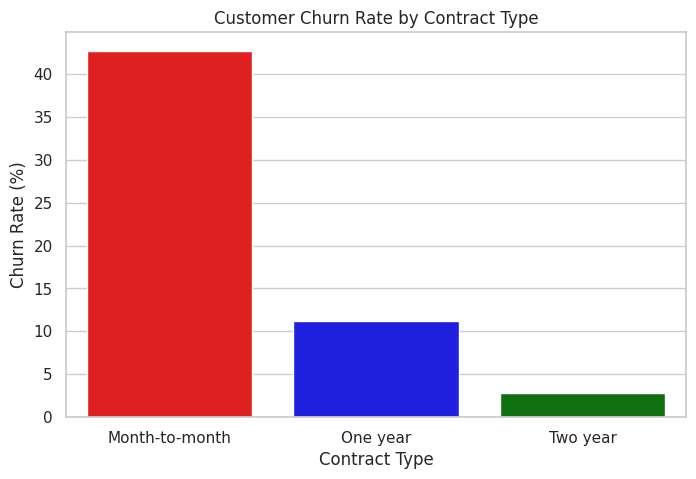

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn["Yes"],
    hue=contract_churn.index,
    palette=["red", "blue", "green"],
    legend=False
)

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

# **Business Insights**
 **Based on the chart:**
 1. Month-to-month contracts have the highest churn rate, at approximately 42–43%, making them the biggest source of customer loss.
2. One-year contracts have much lower churn, at around 11%, suggesting that longer commitments improve customer retention.
3. Two-year contracts have the lowest churn, at approximately 3%, indicating very strong customer loyalty among long-term contract customers.
4. Customers on month-to-month contracts are roughly 4 times more likely to churn than customers on one-year contracts.
5. Compared with two-year contracts, month-to-month customers have more than 14 times the churn rate, showing a major retention gap.
6. The data suggests that contract duration is strongly associated with customer retention—the longer the contract, the lower the churn.
7. The business could focus on converting month-to-month customers into annual or two-year contracts, potentially through discounts, loyalty benefits, or contract-upgrade incentives.
8. Retention efforts should prioritize month-to-month customers, since reducing churn in this segment is likely to have the greatest impact on overall customer retention.

**Final Insight**

The key business insight is that longer-term contracts are strongly associated with lower customer churn. The extremely high churn among month-to-month customers presents both a risk and an opportunity: by encouraging these customers to move toward one- or two-year contracts, the company can potentially improve customer loyalty and significantly reduce overall churn.

#**3. Customer Distribution by Internet Service — Pie Chart**

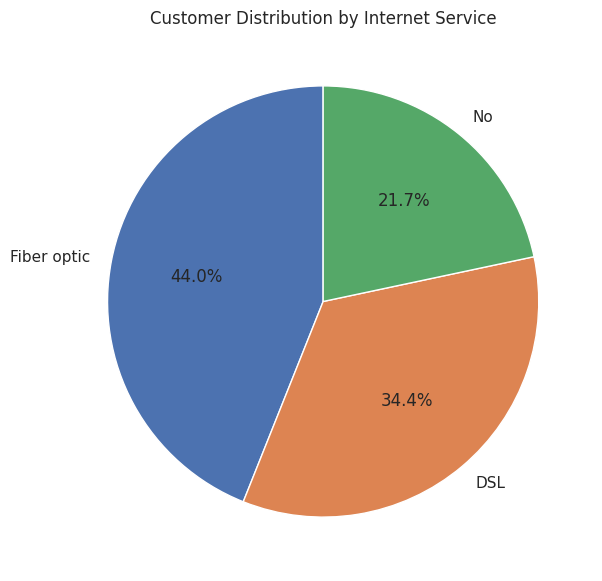

In [ ]:
internet_counts = df["Internet Service"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    internet_counts,
    labels=internet_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Distribution by Internet Service")

plt.show()

#**Business Insights**
**Based on the chart:**
1. Fiber optic is the most common internet service, accounting for 44.0% of customers.
2. DSL customers represent 34.4%, making DSL the second-largest service category.
3. 21.7% of customers do not have internet service, indicating a significant segment without internet connectivity.
4. Fiber optic customers are 9.6 percentage points higher than DSL customers, showing stronger adoption of fiber.
5. Fiber optic and DSL together account for 78.4% of customers, meaning internet services are widely adopted.
6. The 21.7% without internet service could represent an opportunity for targeted internet-service offers or upgrades.
7. Since fiber optic has the largest customer share, fiber service quality and customer experience should be a major retention priority.
8. The distribution suggests a potential migration opportunity from DSL to fiber optic, particularly as customers seek faster and more modern connectivity.

**Final Insight**

Fiber optic is the dominant internet service, while a sizeable 21.7% of customers have no internet service. The company should focus on retaining fiber customers, upgrading suitable DSL customers to fiber, and targeting customers without internet service with attractive connectivity offers.






#**4. Distribution of Monthly Charges — Histogram**

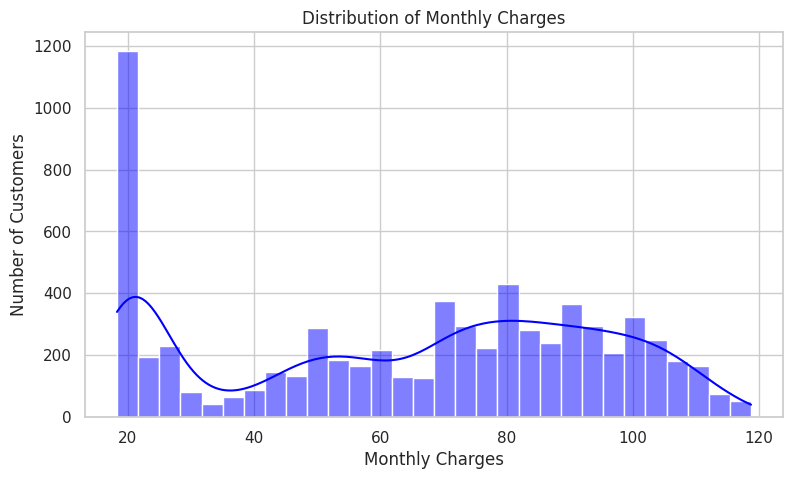

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(df["Monthly Charges"], bins=30,color="blue", kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

#**Monthly Charges – Business Insights**
**Based on the chart:**
1. The highest number of customers have monthly charges around \$20.

2. Monthly charges range from approximately \$20 to \$120, showing wide variation in customer spending.

3. A large customer group is concentrated between \$70 and \$105.

4. The \$80 charge level shows a noticeable peak, indicating a popular pricing point.

5. Customers can be divided into low-, medium-, and high-charge segments.

6. The \$30–\$40 range has relatively fewer customers compared with other charge levels.

7. Customers paying between \$100 and \$120 represent a smaller but potentially high-value segment.

8. The business can increase revenue by encouraging low-charge customers to upgrade to higher-value plans.

**Final Insight**

The monthly charge distribution shows a large low-value customer segment and a strong mid-to-high-value segment, creating opportunities for customer upgrades and revenue growth.

#**5. Distribution of Customer Tenure — Histogram**

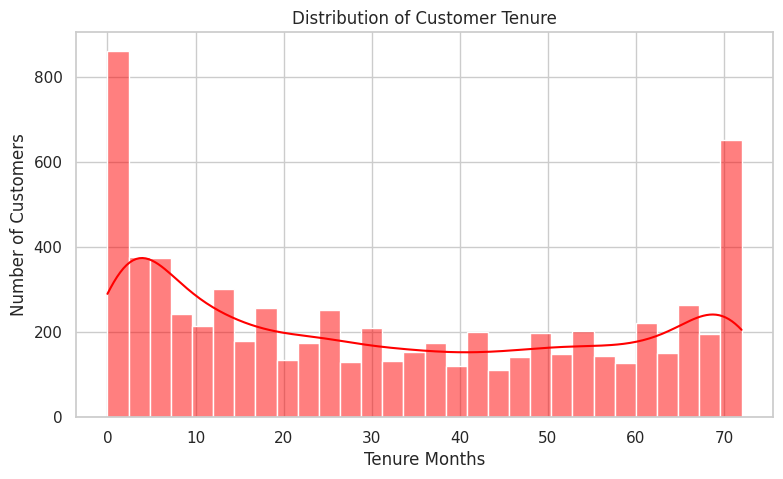

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(df["Tenure Months"], bins=30, color="red", kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure Months")
plt.ylabel("Number of Customers")

plt.show()

#**Customer Tenure – Business Insights**
**Based on the chart:**
1. A large number of customers have very short tenure (0–5 months).
2. The highest concentration is at 1 month, with around 850 customers.
3. This indicates that the business has a significant number of new customers.
4. Customer numbers generally decrease as tenure increases, showing challenges in long-term retention.
5. There is another noticeable increase around 70–72 months, indicating a group of highly loyal long-term customers.
6. Customers with 60+ months of tenure represent an important loyal segment.
7. The company should focus on the early customer journey, especially during the first few months, to prevent early churn.
8. Long-tenure customers can be targeted with loyalty programs, rewards, and retention benefits.

**Final Insight**

The customer base has a large concentration of new customers but also a strong group of long-term customers. The major business opportunity is to improve early-stage retention and convert new customers into long-term, loyal customers.

#**6. Monthly Charges vs Total Charges — Scatter Plot**

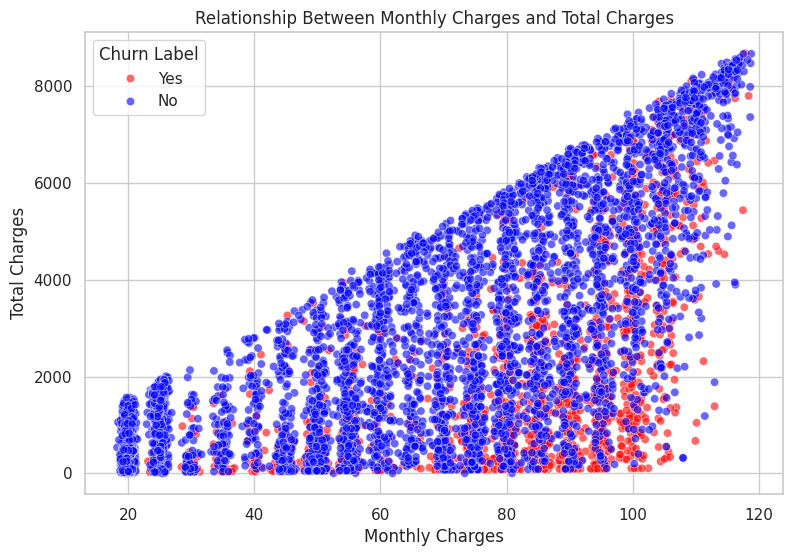

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Monthly Charges",
    y="Total Charges",
    hue="Churn Label",
    palette={"Yes": "red", "No": "blue"},
    alpha=0.6
)

plt.title("Relationship Between Monthly Charges and Total Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.legend(title="Churn Label")

plt.show()

#**Monthly Charges vs Total Charges – Business Insights**
**Based on the chart:**
1. There is a strong positive relationship between Monthly Charges and Total Charges.

2. Customers with higher monthly charges generally have higher total charges.

3. Total charges increase substantially as monthly charges move from around \$20 to \$120.

4. Customers with monthly charges above $80 contribute significantly to higher total charges.

5. The highest total charges are concentrated around customers paying approximately \$100–\$118 per month.

6. Customers who have churned (red) are more concentrated in the lower total-charge region compared with non-churned customers.

7. Non-churned customers (blue) are widely distributed across higher total-charge values, indicating stronger long-term revenue contribution.

8. The combination of high monthly and total charges represents an important high-value customer segment that should be prioritized for retention.

**Final Insight**

Monthly Charges have a strong positive relationship with Total Charges, while non-churned customers appear more strongly represented among high-value customers, highlighting the importance of retaining customers with higher revenue potential.

#**7. Customer Churn Rate by Payment Method — Horizontal Bar Chart**

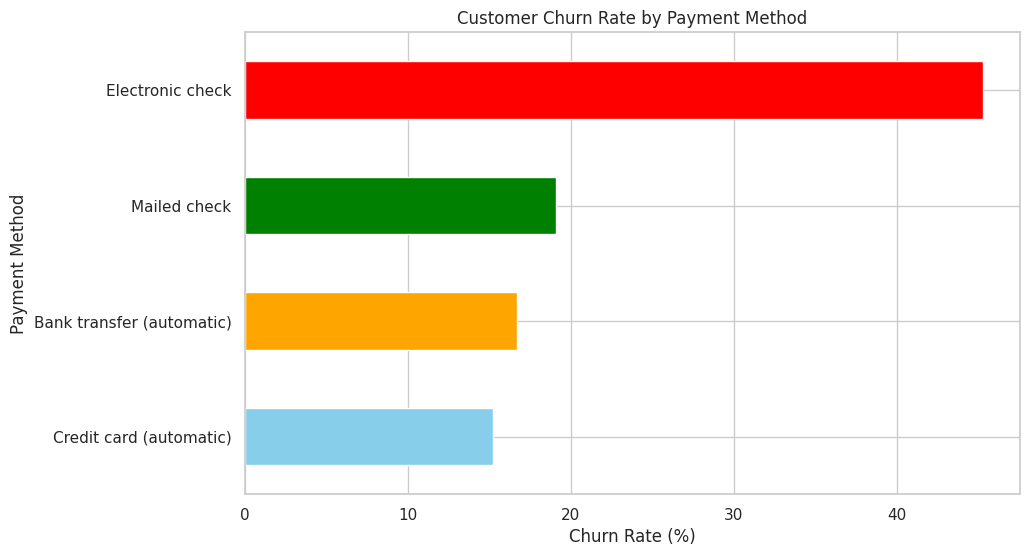

In [ ]:
payment_churn = (
    pd.crosstab(df["Payment Method"], df["Churn Label"], normalize="index") * 100
)

plt.figure(figsize=(10, 6))

payment_churn["Yes"].sort_values().plot(
    kind="barh",
    color=["skyblue", "orange", "green", "red", "purple"]
)

plt.title("Customer Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")

plt.show()

#**Payment Method – Business Insights**
**Based on the chart:**
1. Electronic check has the highest churn rate, at approximately 45%.
2. Customers using mailed checks have a churn rate of around 19%.
3. Bank transfer (automatic) has a lower churn rate of approximately 17%.
4. Credit card (automatic) has the lowest churn rate, at around 15%.
5. Electronic-check customers are far more likely to churn than customers using automatic payment methods.
6. Automatic payment methods appear to be associated with better customer retention.
7. The company should encourage electronic-check customers to switch to automatic bank transfer or credit-card payments.
8. Offering incentives such as discounts, convenience benefits, or auto-pay rewards could help reduce payment-related churn.

**Final Insight**

Electronic check customers have by far the highest churn rate (~45%), while automatic payment methods have much lower churn. The company should encourage customers to adopt automatic payment methods to improve retention and reduce churn.


#**8. Customer Churn Rate by Internet Service — Bar Chart**

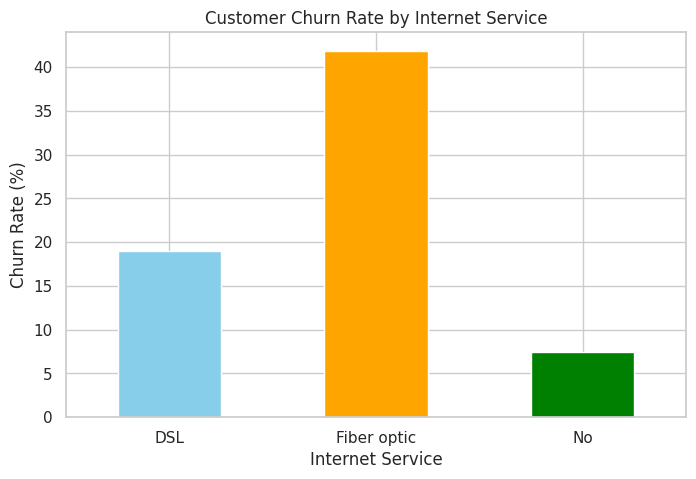

In [ ]:
internet_churn = (
    pd.crosstab(
        df["Internet Service"],
        df["Churn Label"],
        normalize="index"
    ) * 100
)

plt.figure(figsize=(8, 5))

internet_churn["Yes"].plot(
    kind="bar",
    color=["skyblue", "orange", "green"]
)

plt.title("Customer Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

#**Customer Churn Rate by Internet Service – Business Insights**
**Based on the chart:**
1. Fiber optic customers have the highest churn rate, at approximately 42%.
2. DSL customers have a churn rate of around 19%, which is significantly lower than fiber optic.
3. Customers with no internet service have the lowest churn rate, at approximately 7%.
4. Fiber optic customers are more than twice as likely to churn as DSL customers.
5. The high churn among fiber optic users may indicate pricing, service quality, customer expectations, or technical issues.
6. The company should investigate why fiber optic customers are leaving despite using a premium service.
7. Improving fiber service quality and offering competitive pricing or retention benefits could help reduce churn.
8. Customers with no internet service have relatively low churn, suggesting that internet-service availability alone does not guarantee retention.

**Final Insight**

Fiber optic customers show the highest churn rate (~42%), making them the most important segment for retention efforts. The company should investigate pricing, service quality, and customer experience issues among fiber users to reduce churn.

#**9. Top 10 Cities by Customer Base — Horizontal Bar Chart**

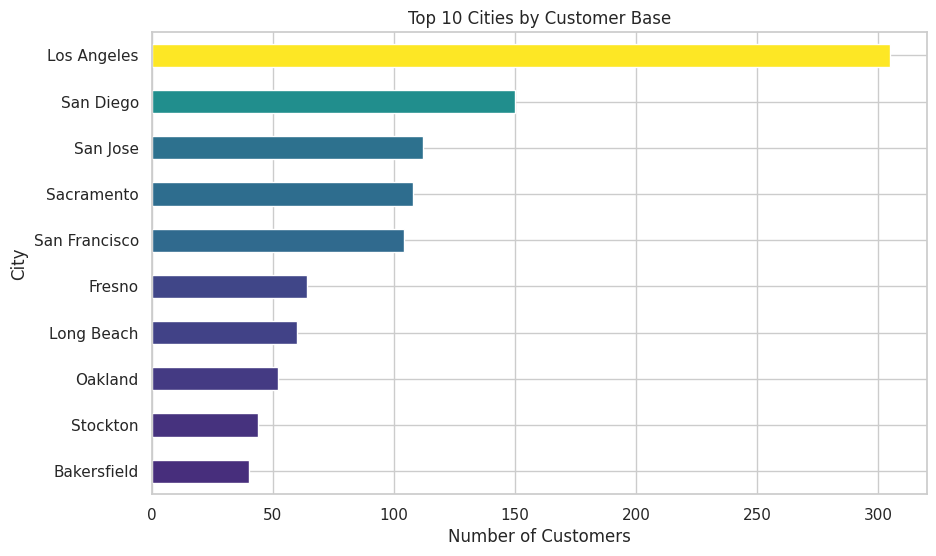

In [ ]:
top_cities = df["City"].value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))

colors = plt.cm.viridis(
    top_cities.values / top_cities.values.max()
)

top_cities.plot(
    kind="barh",
    color=colors
)

plt.title("Top 10 Cities by Customer Base")
plt.xlabel("Number of Customers")
plt.ylabel("City")

plt.show()

#**Top 10 Cities by Customer Base – Business Insights**
**Based on the chart:**
1. Los Angeles has the largest customer base, with approximately 305 customers.
2. San Diego ranks second, with around 150 customers.
3. Los Angeles has about twice the customers of San Diego, showing a strong concentration in this market.
4. San Jose, Sacramento, and San Francisco each have around 100–115 customers.
5. Fresno and Long Beach have approximately 60–65 customers each.
6. Oakland, Stockton, and Bakersfield have the smallest customer bases among the top 10 cities.
7. The customer base is highly concentrated in major cities, particularly Los Angeles and San Diego.
8. The company has a strong opportunity to increase customer acquisition in smaller cities where the current customer base is relatively low.

**Final Insight**

Los Angeles is the largest market with approximately 305 customers, followed by San Diego with about 150. The company should prioritize retention and growth in Los Angeles while expanding customer acquisition in smaller cities to achieve more balanced market growth.

#**10. Average Monthly Charges by Customer Tenure__Line plot**

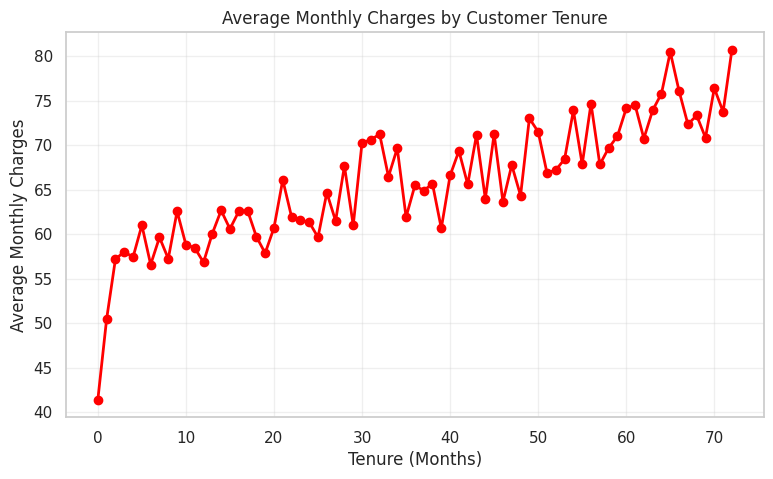

In [ ]:


# Average Monthly Charges by Tenure
avg_charges = (
    df.groupby("Tenure Months")["Monthly Charges"]
    .mean()
    .sort_index()
)

# Line Plot
plt.figure(figsize=(9, 5))

plt.plot(
    avg_charges.index,
    avg_charges.values,
    color="red",
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Charges by Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Average Monthly Charges")

plt.grid(True, alpha=0.3)
plt.show()

#**Line Plot – Business Insights**
**Based on the chart:**
1. Average monthly charges generally increase as customer tenure increases.

2. New customers have the lowest average monthly charges, starting at around \$41.

3. Average charges rise to approximately \$57–\$62 during the first 10 months.

4. Customers with around 30–35 months of tenure have average charges of approximately \$66–\$71.

5. After 50 months, average monthly charges are generally above \$67.

6. Customers with 60+ months of tenure show higher average charges, mostly around \$71–\$80.

7. The highest average monthly charge is approximately \$81 for a long-tenure customer group.

8. The upward trend suggests that longer-tenure customers tend to have higher-value plans or services.


**Final Insight**

Average monthly charges increase with customer tenure, indicating that long-term customers generally generate higher monthly revenue than newer customers.


#**11. Monthly Charges Distribution by Churn Status - Box plot**

/tmp/ipykernel_2681/731520626.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


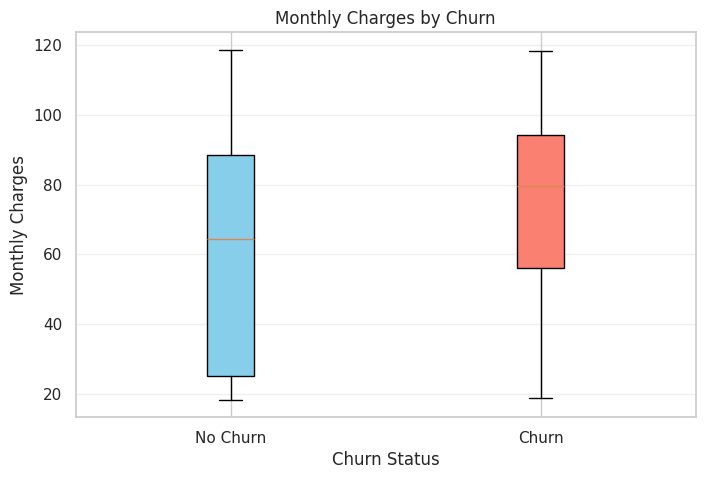

In [ ]:
# Separate data by churn
no_churn = df[df["Churn Label"] == "No"]["Monthly Charges"]
yes_churn = df[df["Churn Label"] == "Yes"]["Monthly Charges"]

# Create box plot
fig, ax = plt.subplots(figsize=(8, 5))

box = ax.boxplot(
    [no_churn, yes_churn],
    labels=["No Churn", "Churn"],
    patch_artist=True
)

# Add different colors
box["boxes"][0].set_facecolor("skyblue")
box["boxes"][1].set_facecolor("salmon")

# Title and labels
ax.set_title("Monthly Charges by Churn")
ax.set_xlabel("Churn Status")
ax.set_ylabel("Monthly Charges")

# Grid
ax.grid(axis="y", alpha=0.3)

plt.show()

#**Box Plot – Business Insights**
**Based on the chart:**
1. Churned customers have a higher median monthly charge of approximately \$80.

2. Non-churned customers have a lower median monthly charge of approximately \$64.

3. Churned customers generally pay higher monthly charges than non-churned customers.

4. The middle 50% of churned customers pay approximately \$56–\$94 per month.

5. The middle 50% of non-churned customers pay approximately\$25–\$89 per month.

6. Both groups have a similar maximum monthly charge of approximately \$118.

7. Non-churned customers show a wider spread in monthly charges, indicating greater variation in their spending.

8. Higher monthly charges may be associated with a greater likelihood of customer churn.

**Final Insight**

Customers with higher monthly charges appear more likely to churn, suggesting that pricing and plan value should be carefully reviewed to improve customer retention.

#**12. Correlation Heatmap of Numerical Features — Heatmap**

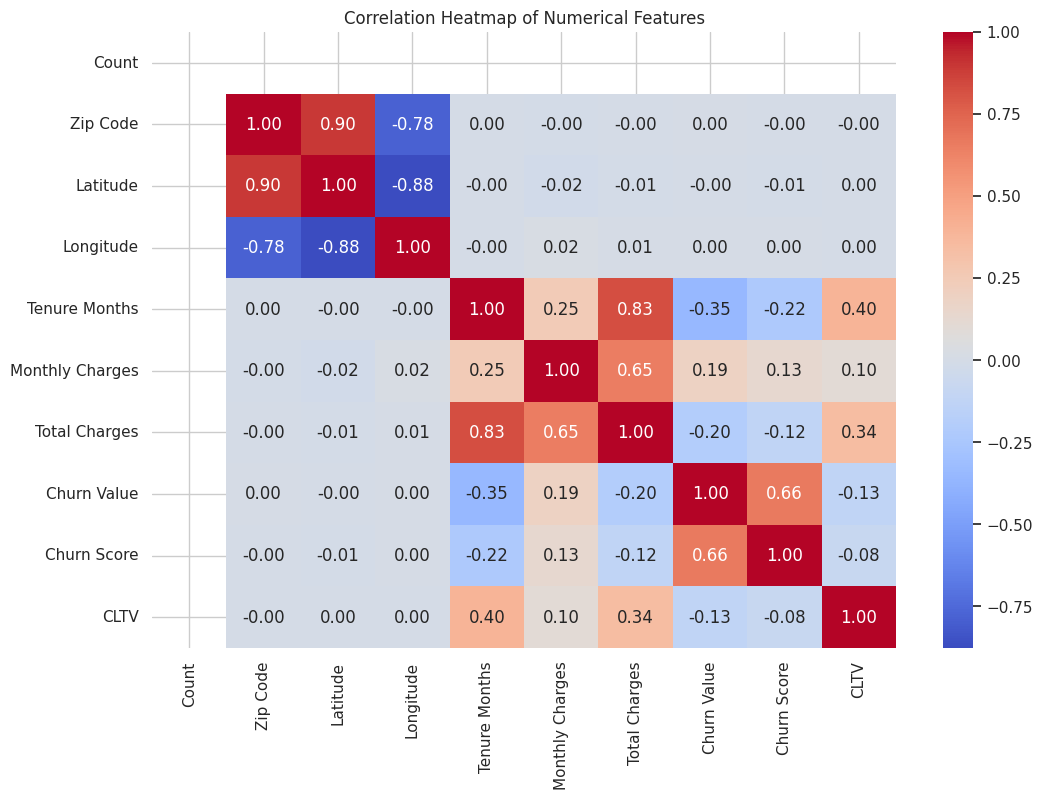

In [ ]:
# Select numerical columns
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

#**Correlation Heatmap – Business Insights**
**Based on the chart:**
1. Tenure Months and Total Charges have a strong positive correlation (0.83), meaning customers who stay longer generally generate higher total revenue.
2. Monthly Charges and Total Charges have a moderate-to-strong positive correlation (0.65), showing that higher-paying customers contribute more to total revenue.
3. Churn Value and Churn Score have a strong positive correlation (0.66), indicating that higher churn-risk scores are closely associated with actual churn.
4. Tenure Months and CLTV have a moderate positive correlation (0.40), suggesting that longer-tenured customers generally have higher lifetime value.
5. Tenure Months and Churn Value have a negative correlation (-0.35), indicating that customers with longer tenure tend to have lower churn.
6. Total Charges and Churn Value show a negative correlation (-0.20), suggesting that customers with higher accumulated charges are somewhat less likely to churn.
7. Monthly Charges and Tenure Months have a weak positive correlation (0.25), meaning longer-tenured customers tend to have slightly higher monthly charges.
8. Geographical variables such as Zip Code, Latitude, and Longitude show strong correlations with each other, but these are mainly due to geographic location and may not directly indicate customer behavior.

**Final Insight**

The strongest business relationship is between tenure and total charges (0.83), showing that retaining customers for longer significantly increases their accumulated value. Since longer tenure is also associated with lower churn, improving early customer retention can simultaneously reduce churn and increase customer lifetime value (CLTV).

#**Business Insights – All Graphs (12 Points)**
1. Customer churn is a major business concern, with around 1,850 customers having churned, compared with more than 5,100 customers who stayed.
2. Contract type strongly impacts churn. Month-to-month customers have the highest churn rate at approximately 43%, compared with 11% for one-year and only 3% for two-year contracts.
3. Fiber optic customers show the highest churn rate, at approximately 42%, compared with around 19% for DSL and 7% for customers without internet service.
4. Payment method is strongly associated with churn. Electronic-check customers have the highest churn rate at approximately 45%, while automatic credit-card payments have the lowest at around 15%.
5. Customer tenure is important for retention. A large number of customers are concentrated in the first few months, indicating that early-stage customer retention is a key challenge.
6. There is also a strong group of customers with long tenure (around 70+ months), representing a valuable loyal customer segment.
7. Monthly charges show a wide distribution, with many customers paying around the lower charge range and another large concentration around ₹6,000–₹9,000 approximately after converting from USD.
8. The relationship between Monthly Charges and Total Charges is strongly positive. Customers with higher monthly charges generally generate higher total revenue over their lifetime.
9. Higher-paying customers are also visible among churned customers, suggesting that losing high-value customers can have a significant impact on business revenue.
10. Los Angeles has the largest customer base, with approximately 305 customers, followed by San Diego with around 150 customers. This indicates that customer concentration is highest in major cities.
11. The line plot shows that average monthly charges generally increase with customer tenure, suggesting that long-term customers tend to purchase higher-value services or plans.
12. The correlation heatmap shows that Tenure and Total Charges have a very strong positive correlation (0.83), while Tenure and Churn have a negative correlation (-0.35). This indicates that retaining customers longer can increase revenue and reduce churn.

#**Enhanced Business Perspective**

1. Customer Retention: The high churn among month-to-month customers indicates a strong opportunity to convert them into one-year or two-year contracts through discounts and loyalty benefits.

2. High-Risk Customer Segments: Fiber-optic users and electronic-check customers show significantly higher churn, making them priority segments for targeted retention campaigns.

3. Early Customer Engagement: The large concentration of customers with short tenure suggests that the first 3–6 months are critical. Welcome programs, onboarding support, and early engagement can improve retention.
4. Revenue Protection: Customers with higher monthly charges represent high-value revenue opportunities. Preventing churn in this segment can have a greater financial impact than retaining low-value customers.
5. Payment Optimization: Encouraging customers to use automatic credit card or bank transfer payments could improve payment convenience and potentially reduce churn.
6. Customer Lifetime Value: The strong relationship between tenure and total charges (0.83) shows that retaining customers longer can significantly increase their overall contribution to revenue.
7. Long-Term Customer Strategy: Customers with 60+ months of tenure represent a valuable loyal segment. Loyalty rewards, upgrades, and personalized offers can help maintain their relationship.
8. Pricing Strategy: Since churned customers have a higher median monthly charge, the company should review pricing, perceived value, and premium-plan benefits to reduce price-related dissatisfaction.
9. Geographic Opportunity: Los Angeles has the largest customer base, so it should receive strong retention and marketing investment, while smaller cities can be targeted for customer acquisition.
10. Upselling Opportunity: The upward trend in average monthly charges with tenure suggests opportunities for cross-selling and premium-plan upgrades among established customers.
11. Data-Driven Churn Prediction: The correlation between Churn Value and Churn Score (0.66) indicates that churn-risk scores can be useful for identifying customers who need proactive retention efforts.
12. Overall Business Strategy: The company should combine contract conversion, payment-method optimization, early engagement, premium-customer retention, and personalized offers to reduce churn and increase Customer Lifetime Value.

#**Final Business Insight**

The analysis shows that customer churn is mainly concentrated among month-to-month contract customers, fiber-optic users, electronic-check users, and customers with higher monthly charges. The company should focus on converting month-to-month customers into long-term contracts, encouraging automatic payment methods, improving the fiber-optic customer experience, and strengthening retention during the first few months. These actions can reduce churn, increase customer lifetime value, and improve overall revenue.